# RPC metrics with a KSG (nearest-neighbour) mutual information estimator

This notebook is the counterpart of `calc_RPC.ipynb`. The pre-processing, the
variance-based RPC ($\rho$) and every figure are the same; the only thing that changes is
**how mutual information is estimated**.

| | `calc_RPC.ipynb` | this notebook |
|---|---|---|
| MI estimator | 2-D histogram, Freedman-Diaconis bins | KSG $k$-nearest-neighbour, rank/copula transform |
| ensemble handling | *jugaad* flattening: obs tiled $N\times$, members pooled into one 1-D sample | each time step is one sample, the $N$ members are $N$ **dimensions** |
| free parameter | bin count (varied $\times 0.5, 1, 1.5$) | neighbour count $k$ (varied $3, 5, 10$) |

Because the KSG estimator consumes the ensemble jointly rather than pooling members, two
parts of the published recipe have no literal translation. Both are spelled out in
"Three things that do not translate directly" below — read that before using the numbers.

**Runtime.** The full grid is $64\times128=8192$ points and every point needs its own
kd-trees, so a cold run is roughly 20 minutes. Results are cached to
`../data/ksg_rpc_cache.npz`; set `USE_CACHE = False` to force a recompute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib import rc
import xarray as xr
import pandas as pd
from tqdm import tqdm
import warnings
import os
import cartopy.crs as ccrs
from scipy.stats import skew, kurtosis, rankdata, iqr
from scipy.spatial import cKDTree
from scipy.special import digamma
from numpy import nanmean, nanvar

In [2]:
# Setting the fonts for matplotlib
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

# uncomment to return fonts to default settings
# plt.rcdefaults()

# Pre-processing

Identical to `calc_RPC.ipynb` cell 3, with one guard: the observation file on disk now
carries a plain `datetime64` time axis rather than a `cftime` one, so
`obs.indexes["time"].to_datetimeindex()` raises `AttributeError`. The call is a no-op on a
`DatetimeIndex`, so it is applied only when the index actually needs converting; results
are bit-identical either way. `calc_RPC.ipynb` carries the same guard.

In [3]:
# Load in the datasets
f = xr.open_dataset("../data/ensembles/large_psl_decadal_ensemble_no_extrapolate.nc").drop_dims(["bnds"])
obs = xr.open_dataset("../data/obs/hadslp2/hadslp2_monthly_1850_2004.nc")
obs = obs.where(obs["time.year"]>=1962, drop=True)
obs = obs.where(obs["time.year"]<1972, drop=True)
obs = obs.sortby("lon")

# Interpolate the observations to match the model outputs
with warnings.catch_warnings(action="ignore"):
    # hasattr guard: no-op when the file already stores datetime64 rather than cftime
    idx = obs.indexes["time"]
    obs["time"] = idx.to_datetimeindex() if hasattr(idx, "to_datetimeindex") else idx
obs = obs.interp_like(f, kwargs={"fill_value":"extrapolate"})

# Linearly detrend the data
obs_lin_trend = xr.polyval(obs["time"], obs.psl.polyfit(dim='time', deg=1).polyfit_coefficients)
obs["psl"] = obs["psl"] - obs_lin_trend

f_lin_trend = xr.polyval(f["time"], f.psl.polyfit(dim='time', skipna=True, deg=1).polyfit_coefficients)
f["psl"] = f["psl"] - f_lin_trend

s = f.mean("n")

# Inspecting the Data

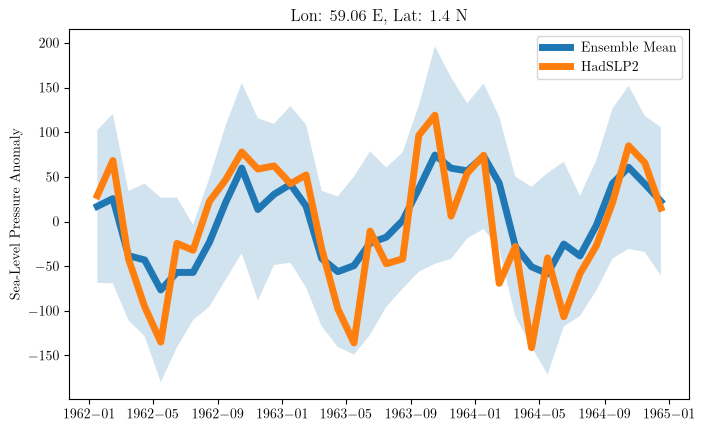

In [4]:
def inspect_data(lat_idx, lon_idx):
    lat, lon = lat_idx, lon_idx
    T_STOP = 36
    t = f.time.to_numpy().astype("datetime64[m]")
    t = t[:T_STOP]
    f_xy = f.isel(lat=lat, lon=lon).psl.to_numpy()
    f_xy = f_xy[:,:T_STOP]
    s_xy = np.mean(f_xy, axis=0)
    model_spread = np.std(f_xy, axis=0)
    g_xy = obs.isel(lat=lat, lon=lon).psl.to_numpy()
    g_xy = g_xy[:T_STOP]

    fig = plt.figure()
    plt.plot(t, s_xy, linewidth=5, label='Ensemble Mean')
    plt.fill_between(t, s_xy-model_spread, s_xy+model_spread, interpolate=True, alpha=0.2)
    plt.plot(t, g_xy, linewidth=5, label='HadSLP2')
    plt.legend()
    plt.ylabel("Sea-Level Pressure Anomaly")
    fig.set_figwidth(8)

    plt.title(f"Lon: {np.round(f.lon[lon].to_numpy(), 2)} E, Lat: {np.round(f.lat[lat].to_numpy(), 2)} N")
inspect_data(32, 21)

# Make histograms of the climate model outputs and the observation data

In [5]:
# flatten the data in order to make the histograms
flat_s = s.psl.to_numpy().flatten()
flat_obs = obs.psl.to_numpy().flatten()
flat_obs = flat_obs[~np.isnan(flat_obs)]
flat_f = f.psl.to_numpy().flatten()
flat_s = flat_s[~np.isnan(flat_s)]
flat_obs = flat_obs[~np.isnan(flat_obs)]
flat_f = flat_f[~np.isnan(flat_f)]

s_bins, s_edges = np.histogram(flat_s, bins=100, density=True)
obs_bins, obs_edges = np.histogram(flat_obs, bins=100, density=True)
f_bins, f_edges = np.histogram(flat_f, bins=1000, density=True)

s_mean, s_var, s_skew, s_kurt = np.round(nanmean(flat_s), 3), np.round(nanvar(flat_s),3), np.round(skew(flat_s),3), np.round(kurtosis(flat_s),3)
obs_mean, obs_var, obs_skew, obs_kurt = np.round(nanmean(flat_obs), 3), np.round(nanvar(flat_obs),3), np.round(skew(flat_obs),3), np.round(kurtosis(flat_obs),3)
f_mean, f_var, f_skew, f_kurt = np.round(nanmean(flat_f), 3), np.round(nanvar(flat_f),3), np.round(skew(flat_f),3), np.round(kurtosis(flat_f),3)

Sig -- mean=0.063 | var=104400.226 | skew=-0.288 | kurt=2.588
Obs -- mean=-0.0 | var=155033.895 | skew=0.136 | kurt=2.27
Ens -- mean=-0.0 | var=260389.658 | skew=0.014 | kurt=1.661


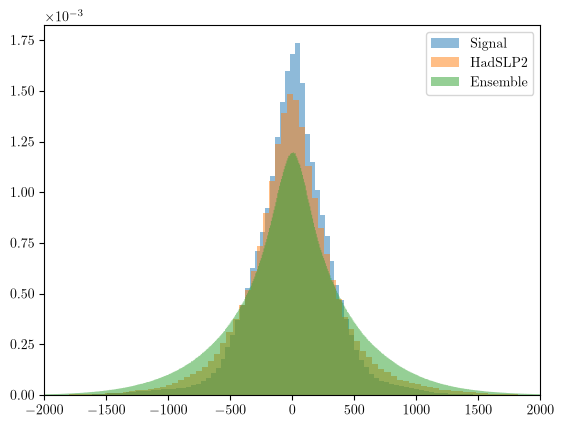

In [6]:
print(f"Sig -- mean={s_mean} | var={s_var} | skew={s_skew} | kurt={s_kurt}")
print(f"Obs -- mean={obs_mean} | var={obs_var} | skew={obs_skew} | kurt={obs_kurt}")
print(f"Ens -- mean={f_mean} | var={f_var} | skew={f_skew} | kurt={f_kurt}")

plt.stairs(s_bins, s_edges, fill=True, alpha=0.5, label='Signal')
plt.stairs(obs_bins, obs_edges, fill=True, alpha=0.5, label='HadSLP2')
plt.stairs(f_bins, f_edges, fill=True, alpha=0.5, label='Ensemble')
plt.legend()
plt.xlim([-2000, 2000])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0));

# Estimate the RPC from the data

In [7]:
def var_RPC(ensemble:xr.Dataset, signal:xr.Dataset, observation:xr.Dataset):
    rho_o = xr.corr(signal.psl, observation.psl, dim="time")
    rho_o = xr.where(rho_o>0, rho_o, 0)
    var_s = signal.psl.var(dim="time", skipna=True)
    var_total = ensemble.psl.var(dim="time", skipna=True).mean("n")
    rho_m = np.sqrt(var_s / var_total)
    rho = rho_o/rho_m
    return rho_o, rho_m, rho
rho_o, rho_m, rho = var_RPC(f, s, obs)

/Users/jasperchen/Academics/Research/SNP/information-snp/.venv/lib/python3.13/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


# The KSG ensemble mutual information estimator

Estimates $I(F; g)$ where $F$ is the whole ensemble. Each **time step is one sample** and
the $N$ ensemble members are $N$ **dimensions**, so the estimator sees the joint ensemble
distribution instead of a pool of members. A rank/copula transform removes the marginals
first, then the Kraskov-Stogbauer-Grassberger $k$-NN identity gives $I$ in nats, converted
to bits. $\lambda = \sqrt{1 - 2^{-2I}}$ is returned alongside.

In [8]:
def ensemble_MI_KSG(f, g, k=5):
    """
    Estimate I(F; g) nonparametrically using the KSG estimator.

    Parameters
    ----------
    f : array, shape (N_members, T)
        Ensemble forecasts.
    g : array, shape (T,)
        Observations.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    I_bits : float
        Estimated mutual information in bits.
    lam : float
        lambda = sqrt(1 - 2^(-2 I)).
    """
    f = np.asarray(f, dtype=float)
    g = np.asarray(g, dtype=float)

    N, T = f.shape
    if g.shape != (T,):
        raise ValueError("g must have shape (T,) matching f.shape[1]")

    # Each time point is ONE sample; ensemble members are dimensions.
    X = f.T  # shape (T, N)

    # Copula/rank transform: removes marginal distributions
    X = np.column_stack([
        (rankdata(X[:, j]) - 0.5) / T
        for j in range(N)
    ])
    y = ((rankdata(g) - 0.5) / T)[:, None]

    # Joint variable (F, g)
    Z = np.column_stack([X, y])

    # Distance to kth neighbor in joint space, using max norm
    tree_Z = cKDTree(Z)
    distances, _ = tree_Z.query(Z, k=k + 1, p=np.inf)
    eps = np.nextafter(distances[:, k], 0)

    # Count neighbors within same radius in marginal spaces
    tree_X = cKDTree(X)
    tree_y = cKDTree(y)

    n_X = np.array([
        len(tree_X.query_ball_point(X[i], eps[i], p=np.inf)) - 1
        for i in range(T)
    ])

    n_y = np.array([
        len(tree_y.query_ball_point(y[i], eps[i], p=np.inf)) - 1
        for i in range(T)
    ])

    # KSG mutual information, initially in nats
    I_nats = (
        digamma(k)
        + digamma(T)
        - np.mean(digamma(n_X + 1) + digamma(n_y + 1))
    )

    I_bits = I_nats / np.log(2)

    # KSG can be slightly negative from sampling error
    I_for_lambda = max(0.0, I_bits)
    lam = np.sqrt(1.0 - 2.0 ** (-2.0 * I_for_lambda))

    return I_bits, lam

## Three things that do not translate directly

**1. The model side cannot use the ensemble mean.** In `calc_RPC.ipynb` the model-side
information is `I_jugaad(s_t, f_t)`, the MI between the ensemble mean and a *randomly drawn
member*. Feeding the ensemble mean to a joint estimator instead asks for $I(F; s)$, and
$s$ is a deterministic function of $F$, so that quantity is infinite and the estimate just
reports the estimator's ceiling (measured: 0.23 bits at lat 32/lon 21 — indistinguishable
from the observed-side value, i.e. useless).

The perfect-model analogue is used instead: hold out member $i$, treat it as the
pseudo-observation, and feed the remaining $N-1$ members as the ensemble:
$$I_m = \big\langle\, I\big(F_{\setminus i};\, f_i\big) \,\big\rangle_i$$
averaged over `LOO_MEMBERS` held-out members. This is the direct information counterpart of
$\rho_m$ = correlation between the ensemble mean and a single member.

**2. $\gamma$ needs a marginal entropy, which the copula transform destroys.** After the
rank transform every marginal is uniform, so a KSG pipeline has no $H(g)$ or $H(f)$ to
normalise by. To keep $\gamma$ comparable to the published notebook, the **denominators are
left exactly as published**: Freedman-Diaconis-binned discrete entropies of the tiled
observations and the pooled members (the helper functions below are copied verbatim from
`scripts/InfoTheoryMetrics.py`). Only the numerator changes. $\gamma$ here is therefore a
hybrid — bin-free numerator over a bin-dependent denominator. **$\lambda$ and $\rho$ are the
fully bin-free metrics; prefer them when comparing against `calc_RPC.ipynb`.**

**3. NaNs hit a $k$-NN estimator harder than a histogram.** The ensemble is 2.84% NaN and
the pattern is structured, not random: members `n=10..19` (GFDL-CM2p1, decadal1961) cover
1961-01 to 1970-12 while every other model covers 1962-01 to 1971-12, so all of calendar
1971 is missing for those 10 members. The published code sets NaNs to 0.0, which under a
rank transform creates a block of tied coordinates.

`NANFILL` selects the behaviour:

* `"zero"` (default, matches published) — NaN $\to$ 0.0, all 8192 grid points defined.
* `"drop"` — drop any time step with a NaN in the ensemble or the observations. Retains 108
  of 120 time steps at a typical point, but longitude columns 0 and 127 are 20.7% and 42.9%
  NaN (wrap-around is not handled before `interp_like`), and those two columns retain
  **zero** usable time steps, so 128 grid points come back NaN.

The two choices differ by roughly 10% in $I$ at a typical grid point (0.187 vs 0.207 bits).

In [9]:
# --- copied verbatim from scripts/InfoTheoryMetrics.py so this notebook is self-contained ---
# (that module imports sklearn at top level, which is not installed in this environment)

def freedman_diaconis_bins(X):
    return int(np.ptp(X) / (2 * iqr(X) / np.power(len(X), 1/3)))

def prob_normalize(hist_counts):
    return hist_counts.astype(np.float32) / np.sum(hist_counts)

def I(X, Y, nbins_alt=None):
    """ Uses histograms to estimate the mutual information between two arrays of equal lengths. """
    N = len(X)
    if nbins_alt is None:
        XY_counts, _, _ = np.histogram2d(X,Y, bins=int(np.sqrt(N/5)))
    else:
        XY_counts, _, _ = np.histogram2d(X,Y, bins=nbins_alt)
    p_XY = prob_normalize(XY_counts)
    p_X = np.sum(p_XY, axis=1)
    p_Y = np.sum(p_XY, axis=0)
    p_XY = p_XY[np.where(p_XY > 0)]
    p_X = p_X[np.where(p_X>0)]
    p_Y = p_Y[np.where(p_Y>0)]
    H_X = -np.sum(p_X * np.log2(p_X))
    H_Y = -np.sum(p_Y * np.log2(p_Y))
    H_XY = -np.sum(p_XY * np.log2(p_XY))
    return H_X + H_Y - H_XY, H_X, H_Y

def I_jugaad(obs, model_output, nbins_alt=None):
    """ Uses the flattening trick described in the paper to calculate mutual information.
        obs: observation data of length L
        model_output: ensemble model output of size N x L
    """
    N,l = model_output.shape
    obs_jugaad = np.tile(obs, N)
    if type(model_output) is np.ndarray:
        return I(obs_jugaad, model_output.reshape(N*l), nbins_alt=nbins_alt)
    else:
        return I(obs_jugaad, model_output.to_numpy().reshape(N*l), nbins_alt=nbins_alt)

## Grid driver

`info_RPC_KSG` mirrors the return signature of `info_RPC`: four arrays of shape
`(len(KS), n_lat, n_lon)`. The leading axis is the neighbour count $k$ instead of the bin
multiplier, so index `1` is the default ($k=5$) exactly as index `1` was the default bin
count in `calc_RPC.ipynb`, and every downstream plotting cell carries over unchanged.

It also returns two permutation-null fields, `null_o` and `null_m`: the same estimator
applied after shuffling the target in time. That measures the estimator's bias floor at
each grid point, which is not negligible at $N=49$, $T=120$ (see the diagnostic section).

In [10]:
KS = (3, 5, 10)        # neighbour counts; index 1 (k=5) is the default used in the figures
NANFILL = "zero"       # "zero" matches the published code; "drop" removes incomplete steps
LOO_MEMBERS = 12       # held-out members averaged for the model side
N_PERM = 10            # permutations for the bias-floor null
MIN_T = 20             # give up on a grid point with fewer usable time steps than this


def info_RPC_KSG(ensemble:xr.Dataset, signal:xr.Dataset, observation:xr.Dataset,
                 ks=KS, nanfill=NANFILL, loo_members=LOO_MEMBERS,
                 n_perm=N_PERM, min_T=MIN_T, seed=0):
    """
        KSG counterpart of InfoTheoryMetrics.info_RPC.

        Returns I_gf_mat, I_sf_mat, H_f_mat, H_g_mat each of shape (len(ks), n_lat, n_lon),
        plus null_o, null_m of shape (n_lat, n_lon) holding the permutation-null MI floor.

        I_gf: I(F; g)                     -- whole ensemble vs observations, KSG
        I_sf: <I(F_-i; f_i)>_i            -- leave-one-out perfect-model analogue, KSG
        H_g, H_f: Freedman-Diaconis binned entropies, identical to the published code
    """
    N, T, x_len, y_len = ensemble.psl.shape
    F = ensemble.psl.to_numpy()
    G = observation.psl.to_numpy()
    S = signal.psl.to_numpy()

    # evenly spaced held-out members, so both GFDL and non-GFDL models are represented
    held_out = np.unique(np.linspace(0, N - 1, loo_members).round().astype(int))
    rng = np.random.default_rng(seed)

    shape = (len(ks), x_len, y_len)
    I_gf_mat, I_sf_mat = np.full(shape, np.nan), np.full(shape, np.nan)
    H_f_mat, H_g_mat = np.full(shape, np.nan), np.full(shape, np.nan)
    null_o = np.full((x_len, y_len), np.nan)
    null_m = np.full((x_len, y_len), np.nan)

    for lat in tqdm(range(x_len), desc="Calculating KSG Entropy Metrics"):
        for lon in range(y_len):
            g_t = G[:, lat, lon]
            s_t = S[:, lat, lon]
            f_t = F[:, :, lat, lon].copy()

            # ---- entropy denominators: published recipe, always on the zero-filled ensemble
            f_zero = f_t.copy()
            f_zero[np.where(np.isnan(f_zero))] = 0.0
            f_flat = f_zero.flatten()
            s_fill = np.nan_to_num(s_t, nan=0.0)
            f_bins = freedman_diaconis_bins(f_flat)
            g_bins_ext = freedman_diaconis_bins(np.tile(np.nan_to_num(g_t, nan=0.0), N))
            s_bins_ext = freedman_diaconis_bins(np.tile(s_fill, N))
            _, H_g, _ = I_jugaad(np.nan_to_num(g_t, nan=0.0), f_zero,
                                 nbins_alt=(g_bins_ext, f_bins))
            _, _, H_f = I_jugaad(s_fill, f_zero, nbins_alt=(s_bins_ext, f_bins))
            H_g_mat[:, lat, lon] = H_g
            H_f_mat[:, lat, lon] = H_f

            # ---- NaN policy for the KSG estimator
            if nanfill == "zero":
                f_use, g_use = f_zero, np.nan_to_num(g_t, nan=0.0)
            elif nanfill == "drop":
                keep = ~(np.isnan(f_t).any(axis=0) | np.isnan(g_t))
                f_use, g_use = f_t[:, keep], g_t[keep]
            else:
                raise ValueError(f"nanfill {nanfill} not recognized (use 'zero' or 'drop')")

            T_use = g_use.shape[0]
            if T_use < min_T or T_use <= max(ks) + 1:
                continue

            for j, k in enumerate(ks):
                I_gf_mat[j, lat, lon] = ensemble_MI_KSG(f_use, g_use, k=k)[0]
                I_sf_mat[j, lat, lon] = np.mean([
                    ensemble_MI_KSG(np.delete(f_use, i, axis=0), f_use[i], k=k)[0]
                    for i in held_out
                ])

            # ---- permutation null at the default k, one held-out member for the model side
            k_def = ks[len(ks) // 2]
            i0 = held_out[len(held_out) // 2]
            null_o[lat, lon] = np.mean([
                ensemble_MI_KSG(f_use, rng.permutation(g_use), k=k_def)[0]
                for _ in range(n_perm)])
            null_m[lat, lon] = np.mean([
                ensemble_MI_KSG(np.delete(f_use, i0, axis=0), rng.permutation(f_use[i0]),
                                k=k_def)[0]
                for _ in range(n_perm)])

    return I_gf_mat, I_sf_mat, H_f_mat, H_g_mat, null_o, null_m

In [11]:
CACHE = "../data/ksg_rpc_cache.npz"
USE_CACHE = True   # set False to force a recompute (~20 min)

if USE_CACHE and os.path.exists(CACHE):
    _c = np.load(CACHE)
    I_fg, I_fs, H_f, H_g, null_o, null_m = (_c["I_fg"], _c["I_fs"], _c["H_f"],
                                            _c["H_g"], _c["null_o"], _c["null_m"])
    print("loaded cache", CACHE)
else:
    I_fg, I_fs, H_f, H_g, null_o, null_m = info_RPC_KSG(f, s, obs)
    np.savez_compressed(CACHE, I_fg=I_fg, I_fs=I_fs, H_f=H_f, H_g=H_g,
                        null_o=null_o, null_m=null_m, ks=np.array(KS))
    print("computed and cached to", CACHE)

print("shapes:", I_fg.shape, "| k values:", KS)
print("I(F;g)      k=5: mean %.4f  min %.4f  max %.4f bits" % (
    np.nanmean(I_fg[1]), np.nanmin(I_fg[1]), np.nanmax(I_fg[1])))
print("<I(F_-i;f_i)> k=5: mean %.4f  min %.4f  max %.4f bits" % (
    np.nanmean(I_fs[1]), np.nanmin(I_fs[1]), np.nanmax(I_fs[1])))

loaded cache ../data/ksg_rpc_cache.npz
shapes: (3, 64, 128) | k values: (3, 5, 10)
I(F;g)      k=5: mean 0.3951  min 0.0333  max 1.8878 bits
<I(F_-i;f_i)> k=5: mean 0.3796  min 0.0712  max 1.8589 bits


## Metrics

Same algebra as `calc_RPC.ipynb`, with one necessary change: KSG estimates can come out
slightly negative from sampling error, and $\sqrt{1-2^{-2I}}$ is undefined for $I<0$. The
MI is clipped at zero before forming $\lambda$, exactly as `ensemble_MI_KSG` does
internally for its own returned `lam`.

In [12]:
# Calculate the different metrics from the estimated mutual informations
gam_o = I_fg / H_g
gam_m = I_fs / H_f
gam = gam_o / gam_m

# clip at 0 before the lambda transform (KSG can return small negative values)
lam_o = np.sqrt(1 - np.power(2., -2 * np.maximum(I_fg, 0.0)))
lam_m = np.sqrt(1 - np.power(2., -2 * np.maximum(I_fs, 0.0)))
lam = lam_o/lam_m

## Plot the metrics over the surface

Max lambda=1.494, Max rho=2.357


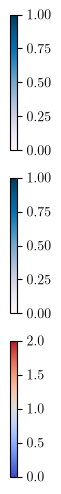

In [13]:
fig, axs = plt.subplots(3,3, subplot_kw=dict(projection=ccrs.PlateCarree()))
_asp = 1.2
cmap = plt.colormaps['PuBu']
cmap2 = plt.colormaps['coolwarm']
PLOT_KWARGS = {"aspect": _asp,
               "origin":"lower",
               "extent":(0, 360, -90, 90),
               "cmap":cmap,
               "transform":ccrs.PlateCarree()
               }

PLOT_KWARGS2 = {"aspect": _asp,
               "origin":"lower",
               "extent":(0, 360, -90, 90),
               "cmap":cmap2,
               "transform":ccrs.PlateCarree()
               }

CBAR_KWARGS = {'fraction':0.01, 'pad':0.03}
# Plot the obs predictable component measures
normalizer = Normalize(0, 1)
im = cm.ScalarMappable(norm=normalizer, cmap=cmap)
axs[0,0].imshow(rho_o, norm=normalizer, **PLOT_KWARGS)
axs[0,1].imshow(gam_o[1], norm=normalizer, **PLOT_KWARGS)
axs[0,2].imshow(lam_o[1], norm=normalizer, **PLOT_KWARGS)
fig.colorbar(im, ax=(axs[0,0], axs[0,1], axs[0,2]), **CBAR_KWARGS)

# Plot the model predictable component measures
axs[1,0].imshow(rho_m, norm=normalizer, **PLOT_KWARGS)
axs[1,1].imshow(gam_m[1], norm=normalizer, **PLOT_KWARGS)
axs[1,2].imshow(lam_m[1], norm=normalizer, **PLOT_KWARGS)
fig.colorbar(im, ax=(axs[1,0], axs[1,1], axs[1,2]), **CBAR_KWARGS)

# Plot the RPC measures
norm2 = Normalize(0,2)
im = cm.ScalarMappable(norm=norm2, cmap=cmap2)
axs[2,0].imshow(rho, norm=norm2, **PLOT_KWARGS2)
axs[2,1].imshow(gam[1], norm=norm2, **PLOT_KWARGS2)
axs[2,2].imshow(lam[1], norm=norm2, **PLOT_KWARGS2)
fig.colorbar(im, ax=(axs[2,0], axs[2,1], axs[2,2]), **CBAR_KWARGS)

fig.set_figwidth(10)
fig.set_figheight(6)
print(f"Max lambda={np.round(np.nanmax(lam),3)}, Max rho={np.round(np.nanmax(rho),3)}")

PLOT_TITLES = np.array([
    [r"(a) $\rho_o$", r"(b) $\gamma_o$", r"(c) $\lambda_o$"],
    [r"(d) $\rho_m$", r"(e) $\gamma_m$", r"(f) $\lambda_m$"],
    [r"(g) $\rho$", r"(h) $\gamma$", r"(i) $\lambda$"]
])
m,n = axs.shape
for i in range(m):
    for j in range(n):
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        if j>=1:
            gl.left_labels=False
        if i<=1:
            gl.bottom_labels=False

        axs[i,j].set_title(PLOT_TITLES[i,j])

In [14]:
print("GAM_O AND GAM_M")
print("MAX:", np.nanmax(gam_o[1].flatten()), np.nanmax(gam_m[1].flatten()))
print("MEAN:", np.nanmean(gam_o[1].flatten()), np.nanmean(gam_m[1].flatten()))

print("LAM_O AND LAM_M")
print("MAX:", np.nanmax(lam_o[1].flatten()), np.nanmax(lam_m[1].flatten()))
print("MEAN:", np.nanmean(lam_o[1].flatten()), np.nanmean(lam_m[1].flatten()))

print("RPC ratios (grid mean):")
print("  rho   =", float(rho.mean(skipna=True)))
print("  gamma =", np.nanmean(gam[1]))
print("  lambda=", np.nanmean(lam[1]))


def frac_over_one(x, weighted=True):
    # Fraction of the surface where RPC > 1, cos(lat)-weighted over finite grid points.
    # The published figures are area-weighted: rho comes out at 72.1% weighted and only
    # 66.4% unweighted, and 72.1% is the published number, which fixes the convention.
    x = np.asarray(x, dtype=float)
    w = np.cos(np.deg2rad(f.lat.to_numpy()))[:, None] * np.ones((1, x.shape[1]))
    m = np.isfinite(x)
    if not weighted:
        return 100.0 * np.mean(x[m] > 1)
    return 100.0 * np.sum(w[m] * (x[m] > 1)) / np.sum(w[m])

print()
print("Surface area with RPC > 1, cos(lat)-weighted (published histogram run:"
      " rho 72.1%, gamma 18.9%, lambda 2.0%):")
for name, arr in [("rho", rho.to_numpy()), ("gamma", gam[1]), ("lambda", lam[1])]:
    print("  %-7s %5.1f%%   (unweighted %5.1f%%)" % (
        name, frac_over_one(arr), frac_over_one(arr, weighted=False)))

GAM_O AND GAM_M
MAX: 0.5342526268605179 0.45908574384772044
MEAN: 0.09579296902122987 0.08382039497852109
LAM_O AND LAM_M
MAX: 0.9627982496535188 0.9612451583163681
MEAN: 0.5842414142350199 0.577865062115504
RPC ratios (grid mean):
  rho   = 1.0137701661969287
  gamma = 1.1241258012443103
  lambda= 1.0107757403377688

Surface area with RPC > 1, cos(lat)-weighted (published histogram run: rho 72.1%, gamma 18.9%, lambda 2.0%):
  rho      72.1%   (unweighted  66.4%)
  gamma    81.2%   (unweighted  77.3%)
  lambda   73.6%   (unweighted  69.0%)


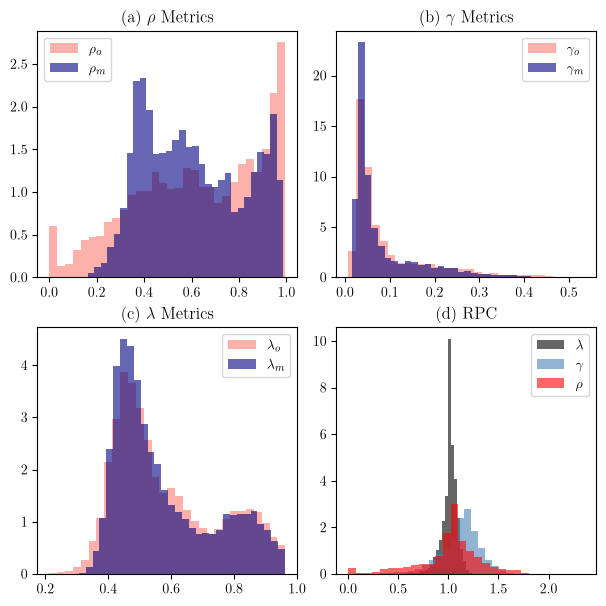

In [15]:
fig, axs = plt.subplots(2,2, figsize=(6,6))
axs[0,0].hist(rho_o.to_numpy().flatten(), alpha=0.6, bins=30, label="$\\rho_o$", color='salmon', density=True)
axs[0,0].hist(rho_m.to_numpy().flatten(), alpha=0.6, bins=30, label="$\\rho_m$", color='navy', density=True)
axs[0,0].legend()
axs[0,0].set_title(r"(a) $\rho$ Metrics")

axs[0,1].hist(gam_o[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma_o$", color='salmon', density=True)
axs[0,1].hist(gam_m[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma_m$", color='navy', density=True)
axs[0,1].set_title(r"(b) $\gamma$ Metrics ")
axs[0,1].legend()

axs[1,0].hist(lam_o[1].flatten(), alpha=0.6, bins=30, label=r"$\lambda_o$", color='salmon', density=True)
axs[1,0].hist(lam_m[1].flatten(), alpha=0.6, bins=30, color='navy', label=r"$\lambda_m$", density=True)
axs[1,0].set_title(r"(c) $\lambda$ Metrics")
axs[1,0].legend()

axs[1,1].hist(lam[1].flatten(), alpha=0.6, bins=30, label=r"$\lambda$", color='black', density=True)
axs[1,1].hist(gam[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma$", color='steelblue', density=True)
axs[1,1].hist(rho.to_numpy().flatten(), alpha=0.6, bins=30, color='red', label="$\\rho$", density=True)
axs[1,1].set_title("(d) RPC")
axs[1,1].legend()

plt.tight_layout(pad=0.5)

# Quantifying $k$ sensitivity

The analogue of the binning-uncertainty section in `calc_RPC.ipynb`. There the spread came
from scaling the Freedman-Diaconis bin count by $0.5$ and $1.5$; here it comes from the
extreme neighbour counts, $k=3$ and $k=10$. As in the published notebook the two longitude
edge columns are patched from their neighbours, because wrap-around is not handled before
`interp_like` and they carry 20.7% and 42.9% NaN.

In [16]:
gam_o_range = np.abs(gam_o[2,:,:] - gam_o[0,:,:])
gam_m_range = np.abs(gam_m[2,:,:] - gam_m[0,:,:])
gam_o_range[:,0] = gam_o_range[:,1]
gam_o_range[:,-1] = gam_o_range[:,-2]
gam_m_range[:,0] = gam_m_range[:,1]
gam_m_range[:,-1] = gam_m_range[:,-2]

lam_o_range = np.abs(lam_o[2,:,:] - lam_o[0,:,:])
lam_m_range = np.abs(lam_m[2,:,:] - lam_m[0,:,:])
lam_o_range[:,0] = lam_o_range[:,1]
lam_o_range[:,-1] = lam_o_range[:,-2]
lam_m_range[:,0] = lam_m_range[:,1]
lam_m_range[:,-1] = lam_m_range[:,-2]

gam_range = np.abs(gam_o[2,:,:]/gam_m[2,:,:] - gam_o[0,:,:]/gam_m[0,:,:])
lam_range = np.abs(lam_o[2,:,:]/lam_m[2,:,:] - lam_o[0,:,:]/lam_m[0,:,:])
gam_range[:,0] = gam_range[:,1]
gam_range[:,-1] = gam_range[:,-2]
lam_range[:,0] = lam_range[:,1]
lam_range[:,-1] = lam_range[:,-2]

In [17]:
print("Mean gam k-sensitivity:", np.nanmean(gam_o_range), np.nanmean(gam_m_range), np.nanmean(gam_range))
print("Mean lambda k-sensitivity:", np.nanmean(lam_o_range), np.nanmean(lam_m_range), np.nanmean(lam_range))

Mean gam k-sensitivity: 0.025878129953382435 0.02208506888907603 0.08048785395469632
Mean lambda k-sensitivity: 0.06631119331947917 0.06587328875768184 0.03283349843565269


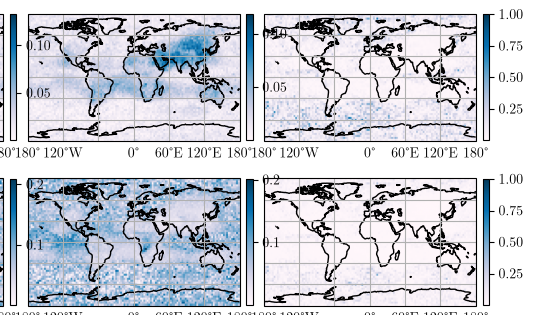

In [18]:
cmap = plt.colormaps['PuBu']
PLOT_KWARGS = {"aspect": 1.2,
               "origin":"lower",
               "extent":(0, 360, -90, 90),
               "cmap":cmap,
               "transform":ccrs.PlateCarree()
               }

fig, axs = plt.subplots(2,3, subplot_kw=dict(projection=ccrs.PlateCarree()))
settings = {"fraction":0.028, "pad":0.03}
im0 = axs[0,0].imshow(gam_o_range, vmax=np.nanmax(gam_o_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im0, ax=axs[0,0], **settings)
im1 = axs[0,1].imshow(gam_m_range, vmax=np.nanmax(gam_m_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im1, ax=axs[0,1], **settings)
im2 = axs[0,2].imshow(gam_range, vmax=1.0, **PLOT_KWARGS)
plt.colorbar(im2, ax=axs[0,2], **settings)

im3 = axs[1,0].imshow(lam_o_range, vmax=np.nanmax(lam_o_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im3, ax=axs[1,0], **settings)
im4 = axs[1,1].imshow(lam_m_range, vmax=np.nanmax(lam_m_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im4, ax=axs[1,1], **settings)
im5 = axs[1,2].imshow(lam_range, vmax=1.0, **PLOT_KWARGS)
plt.colorbar(im5, ax=axs[1,2], **settings)

PLOT_TITLES = [
    [r"(a) $k$-sens. $\gamma_o$", r"(b) $k$-sens. $\gamma_m$", r"(c) $k$-sens. $\gamma$"],
    [r"(d) $k$-sens. $\lambda_o$", r"(e) $k$-sens. $\lambda_m$", r"(f) $k$-sens. $\lambda$"],
]
for i in range(2):
    for j in range(3):
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        if j>=1:
            gl.left_labels = False

        axs[i,j].set_title(PLOT_TITLES[i][j])

fig.set_figwidth(9)
fig.set_figheight(4)
# NOTE: plt.tight_layout() is avoided here. With cartopy 0.25 + shapely 2.1, combining
# tight_layout() with gridlines(draw_labels=True) raises
#   GEOSException: Points of LinearRing do not form a closed linestring
# at draw time (this is what kills cell 21 of calc_RPC.ipynb; its cell 15 survives only
# because it has labelled gridlines but no tight_layout). subplots_adjust is equivalent
# here and does not trigger it.
fig.subplots_adjust(wspace=0.05, hspace=0.15)

In [19]:
print("Mean Observation k-sensitivity:", np.nanmean(gam_o_range))
print("Mean Model k-sensitivity:", np.nanmean(gam_m_range[np.where(gam_m_range<np.inf)]))
print("Mean gamma k-sensitivity:", np.nanmean(gam_range[np.where(gam_range<np.inf)]))

Mean Observation k-sensitivity: 0.025878129953382435
Mean Model k-sensitivity: 0.02208506888907603
Mean gamma k-sensitivity: 0.08048785395469632


# The bias floor: how much of this is real?

A KSG estimator in $N+1$ dimensions with $T$ samples is biased upward, and here
$N+1 = 50$ against $T = 120$ — deep in the under-sampled regime. `null_o` and `null_m`
hold the estimate obtained after shuffling the target in time, which destroys the
dependence while preserving every marginal and the tie structure left by the zero-filled
NaNs. Whatever the estimator returns there is floor, not signal.

Read the panels below before trusting any absolute $\lambda_o$ or $\lambda_m$ value. The
ratio $\lambda = \lambda_o/\lambda_m$ is the more robust quantity, because the floor is
similar on both sides and partially cancels.

In [20]:
frac_o = np.nanmean(null_o / I_fg[1])
frac_m = np.nanmean(null_m / I_fs[1])
print("Permutation-null floor, grid mean:")
print("  observed side: %.4f bits  (%.1f%% of I(F;g) = %.4f)" % (
    np.nanmean(null_o), 100*frac_o, np.nanmean(I_fg[1])))
print("  model side   : %.4f bits  (%.1f%% of <I(F_-i;f_i)> = %.4f)" % (
    np.nanmean(null_m), 100*frac_m, np.nanmean(I_fs[1])))
print("Grid points where I(F;g) does not exceed its own null: %d / %d" % (
    np.nansum(I_fg[1] <= null_o), I_fg[1].size))

# floor-subtracted metrics
I_fg_c = np.maximum(I_fg[1] - null_o, 0.0)
I_fs_c = np.maximum(I_fs[1] - null_m, 0.0)
lam_o_c = np.sqrt(1 - np.power(2., -2*I_fg_c))
lam_m_c = np.sqrt(1 - np.power(2., -2*I_fs_c))
# Where the model side fails to clear its own null, I_fs_c clips to 0, lambda_m_c is
# exactly 0 and the ratio is undefined. Mask those points instead of reporting inf.
n_undef = int(np.sum(lam_m_c == 0))
lam_c = np.where(lam_m_c > 0, lam_o_c / np.where(lam_m_c > 0, lam_m_c, 1.0), np.nan)
print()
print("lambda_o  raw %.3f -> floor-subtracted %.3f" % (np.nanmean(lam_o[1]), np.nanmean(lam_o_c)))
print("lambda_m  raw %.3f -> floor-subtracted %.3f" % (np.nanmean(lam_m[1]), np.nanmean(lam_m_c)))
print("lambda    raw %.3f -> floor-subtracted %.3f  (undefined at %d points where the"
      " model side is below its own null)" % (
          np.nanmean(lam[1]), np.nanmean(lam_c), n_undef))

# The area fractions printed earlier count every grid point, including those whose MI
# never clears its own null -- those inherit the bias floor rather than measuring signal.
# Restrict to points that clear the null on BOTH sides before quoting an area fraction.
clears = (I_fg[1] > null_o) & (I_fs[1] > null_m)
lam_sig = np.where(clears, lam[1], np.nan)
gam_sig = np.where(clears, gam[1], np.nan)
print()
print("Restricted to the %d of %d points clearing both nulls (%.1f%% of the grid):" % (
    int(clears.sum()), clears.size, 100 * clears.mean()))
print("  lambda area > 1: %.1f%%  (unrestricted %.1f%%)" % (
    frac_over_one(lam_sig), frac_over_one(lam[1])))
print("  gamma  area > 1: %.1f%%  (unrestricted %.1f%%)" % (
    frac_over_one(gam_sig), frac_over_one(gam[1])))

Permutation-null floor, grid mean:
  observed side: 0.0793 bits  (35.4% of I(F;g) = 0.3951)
  model side   : 0.0789 bits  (35.0% of <I(F_-i;f_i)> = 0.3796)
Grid points where I(F;g) does not exceed its own null: 113 / 8192

lambda_o  raw 0.584 -> floor-subtracted 0.494
lambda_m  raw 0.578 -> floor-subtracted 0.489
lambda    raw 1.011 -> floor-subtracted 1.017  (undefined at 9 points where the model side is below its own null)

Restricted to the 8070 of 8192 points clearing both nulls (98.5% of the grid):
  lambda area > 1: 74.6%  (unrestricted 73.6%)
  gamma  area > 1: 82.3%  (unrestricted 81.2%)


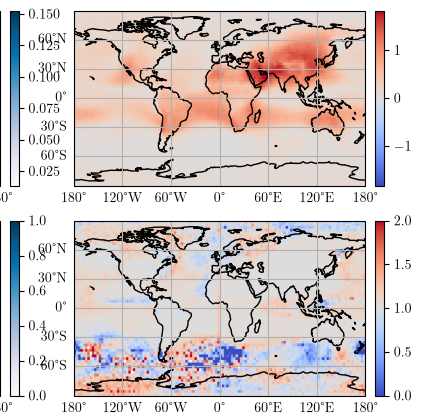

In [21]:
fig, axs = plt.subplots(2,2, subplot_kw=dict(projection=ccrs.PlateCarree()))
PK = {"aspect":1.2, "origin":"lower", "extent":(0,360,-90,90), "transform":ccrs.PlateCarree()}
settings = {"fraction":0.028, "pad":0.03}

im0 = axs[0,0].imshow(null_o, cmap='PuBu', **PK)
plt.colorbar(im0, ax=axs[0,0], **settings)
axs[0,0].set_title(r"(a) null floor, observed side (bits)")

im1 = axs[0,1].imshow(I_fg[1] - null_o, cmap='coolwarm',
                      norm=Normalize(-np.nanmax(np.abs(I_fg[1]-null_o)),
                                      np.nanmax(np.abs(I_fg[1]-null_o))), **PK)
plt.colorbar(im1, ax=axs[0,1], **settings)
axs[0,1].set_title(r"(b) $I(F;g)$ above null (bits)")

im2 = axs[1,0].imshow(lam_o_c, cmap='PuBu', norm=Normalize(0,1), **PK)
plt.colorbar(im2, ax=axs[1,0], **settings)
axs[1,0].set_title(r"(c) $\lambda_o$, floor-subtracted")

im3 = axs[1,1].imshow(lam_c, cmap='coolwarm', norm=Normalize(0,2), **PK)
plt.colorbar(im3, ax=axs[1,1], **settings)
axs[1,1].set_title(r"(d) $\lambda$, floor-subtracted")

for a in axs.flatten():
    a.coastlines()
    gl = a.gridlines(draw_labels=True); gl.top_labels = False; gl.right_labels = False

fig.set_figwidth(9); fig.set_figheight(5)
fig.subplots_adjust(wspace=0.1, hspace=0.2)   # not tight_layout -- see note above

# Summary of what changed, and what to trust

* **$\rho$ is untouched** — it never used mutual information, so it is bit-identical to
  `calc_RPC.ipynb` and is the anchor for comparing the two notebooks. It reproduces the
  published 72.1% of surface area with $\rho > 1$ exactly, which confirms the pre-processing
  here matches the published pipeline. (That match only appears under cos(lat) area
  weighting — unweighted the same field gives 66.4% — so the published percentages are
  area-weighted.)
* **$\lambda$ is the metric to compare.** It is bin-free on both sides, and the
  $\lambda_o/\lambda_m$ ratio cancels much of the estimator's bias floor.
* **$\gamma$ is a hybrid here** — KSG numerator, published Freedman-Diaconis denominator.
  Its absolute magnitude is not comparable to the published $\gamma$; only its spatial
  pattern and its ratio are informative.
* **The model side is a leave-one-out perfect-model estimate**, not the ensemble-mean
  quantity used in the jugaad path, because $I(F;s)$ is degenerate for a joint estimator.
* **The bias floor is large.** At $N=49$ members and $T=120$ months the estimator sits in
  50 dimensions with 120 samples. The permutation null puts the floor at 0.079 bits, about
  35% of the measured $I$ on *both* the observed and the model side. So $\gamma_o$ and
  $\gamma_m$ (and $\lambda_o$, $\lambda_m$) are each inflated, while their **ratio** is much
  less compromised — the ratio is the only defensible KSG statement about the paradox here.
  In particular, "KSG $\gamma$ exceeds 1 over 81% of the surface" is **not** a refutation of
  the published 18.9%: the two numbers come from estimators with completely different bias,
  and only $\rho$ is a like-for-like cross-check between the notebooks.

If the floor turns out to dominate the conclusions, the lever with the most leverage is
dimensionality: run `info_RPC_KSG` on a subset of members (or on ensemble sub-means) so
that $N \ll T$, rather than raising $k$.

---

**Environment note.** With cartopy 0.25 and shapely 2.1, calling `plt.tight_layout()` on a
figure whose axes have `gridlines(draw_labels=True)` raises `GEOSException: Points of
LinearRing do not form a closed linestring` at draw time. It is a layout/label interaction,
not a coastline or data problem — `coastlines()` on its own is fine, and the Natural Earth
shapefile reads with zero invalid geometries. The map cells above use
`fig.subplots_adjust(...)` instead. The same clash is what makes cell 21 of
`calc_RPC.ipynb` fail while its cell 15 succeeds.